In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
DATA_PATH = Path('/content/indianPersonalFinanceAndSpendingHabits.csv')
TARGET_COLUMN = 'Disposable_Income'
CATEGORICAL_COLUMNS = ['Occupation', 'City_Tier']
NUMERICAL_COLUMNS = [
    'Income', 'Age', 'Dependents', 'Rent', 'Loan_Repayment', 'Insurance',
    'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
    'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage',
    'Desired_Savings', 'Potential_Savings_Groceries', 'Potential_Savings_Transport',
    'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
    'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
    'Potential_Savings_Education', 'Potential_Savings_Miscellaneous'
]

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Target column: {TARGET_COLUMN}')
df.head(3)

Dataset shape: (20000, 27)
Target column: Disposable_Income


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422


In [3]:
#Preprocessing
df_processed = df.copy()

label_encoders = {}
for col in CATEGORICAL_COLUMNS:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df[col])
    label_encoders[col] = le

feature_cols = [c for c in NUMERICAL_COLUMNS + CATEGORICAL_COLUMNS if c != TARGET_COLUMN]

X = df_processed[feature_cols].values.astype(np.float32)
y = df_processed[TARGET_COLUMN].values.astype(np.float32).reshape(-1, 1)

feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y).ravel()

#Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f'Train samples : {X_train.shape[0]}')
print(f'Test  samples : {X_test.shape[0]}')
print(f'Input features: {X_train.shape[1]}')

Train samples : 16000
Test  samples : 4000
Input features: 26


In [4]:
class Net(nn.Module):
    """MLP Model for Personal Finance Prediction (Regression)."""

    def __init__(self, input_dim: int = 26):
        super().__init__()
        self.fc1      = nn.Linear(input_dim, 128)
        self.bn1      = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2      = nn.Linear(128, 64)
        self.bn2      = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)

        self.fc4 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
        x = F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)


def train_mlp(model, trainloader, epochs=50, lr=0.001):
    model.to(DEVICE)
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(epochs):
        epoch_loss = 0.0
        for features, targets in trainloader:
            features, targets = features.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            preds = model(features)
            loss  = criterion(preds, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(trainloader))
    return history


@torch.no_grad()
def eval_mlp(model, X_np, y_np):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    preds = model(X_t).cpu().numpy().ravel()
    r2   = r2_score(y_np, preds)
    rmse = mean_squared_error(y_np, preds) ** 0.5
    mae  = mean_absolute_error(y_np, preds)
    return r2, rmse, mae, preds


print('Net architecture:')
print(Net(X_train.shape[1]))

Net architecture:
Net(
  (fc1): Linear(in_features=26, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
)


In [5]:
BATCH_SIZE = 64
MLP_EPOCHS = 100
INPUT_DIM  = X_train.shape[1]

#PyTorch DataLoaders
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
)
trainloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

#Model registry
sklearn_models = {
    'Linear Regression'   : LinearRegression(),
    'k-Nearest Neighbours': KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    'Decision Tree'       : DecisionTreeRegressor(max_depth=10, random_state=SEED),
    'Random Forest'       : RandomForestRegressor(n_estimators=200, max_depth=12,
                                                   n_jobs=-1, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05,
                                                       random_state=SEED),
}

results = {}

#Sklearn training
for name, model in sklearn_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae  = mean_absolute_error(y_test, preds)

    results[name] = dict(R2=r2, RMSE=rmse, MAE=mae,
                         train_time=train_time, preds=preds)
    print(f'{name:<25}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  ({train_time:.1f}s)')

#MLP training
mlp = Net(INPUT_DIM)
t0 = time.time()
mlp_history = train_mlp(mlp, trainloader, epochs=MLP_EPOCHS)
mlp_train_time = time.time() - t0

r2, rmse, mae, mlp_preds = eval_mlp(mlp, X_test, y_test)
results['MLP (PyTorch)'] = dict(R2=r2, RMSE=rmse, MAE=mae,
                                 train_time=mlp_train_time,
                                 preds=mlp_preds, history=mlp_history)
print(f'{"MLP (PyTorch)":<25}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  ({mlp_train_time:.1f}s)')

Linear Regression          R²=1.0000  RMSE=0.0000  MAE=0.0000  (0.0s)
k-Nearest Neighbours       R²=0.8199  RMSE=0.4533  MAE=0.1700  (0.0s)
Decision Tree              R²=0.9350  RMSE=0.2723  MAE=0.1105  (0.5s)
Random Forest              R²=0.9163  RMSE=0.3090  MAE=0.0852  (62.2s)
Gradient Boosting          R²=0.9162  RMSE=0.3092  MAE=0.0747  (63.1s)

Training MLP ...
MLP (PyTorch)              R²=0.9906  RMSE=0.1035  MAE=0.0719  (73.4s)


In [6]:
summary = pd.DataFrame(
    {name: {'R²': v['R2'], 'RMSE': v['RMSE'], 'MAE': v['MAE'],
            'Train time (s)': round(v['train_time'], 2)}
     for name, v in results.items()}
).T.sort_values('R²', ascending=False)

summary = summary.astype({'R²': float, 'RMSE': float, 'MAE': float})

summary.style \
    .format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'Train time (s)': '{:.2f}'}) \
    .set_caption('Model Comparison — Centralized Training (sorted by R²)')

,R²,RMSE,MAE,Train time (s)
Linear Regression,1.0000,0.0000,0.0000,0.03
MLP (PyTorch),0.9906,0.1035,0.0719,73.39
Decision Tree,0.9350,0.2723,0.1105,0.48
Random Forest,0.9163,0.3090,0.0852,62.25
Gradient Boosting,0.9162,0.3092,0.0747,63.10
k-Nearest Neighbours,0.8199,0.4533,0.1700,0.00


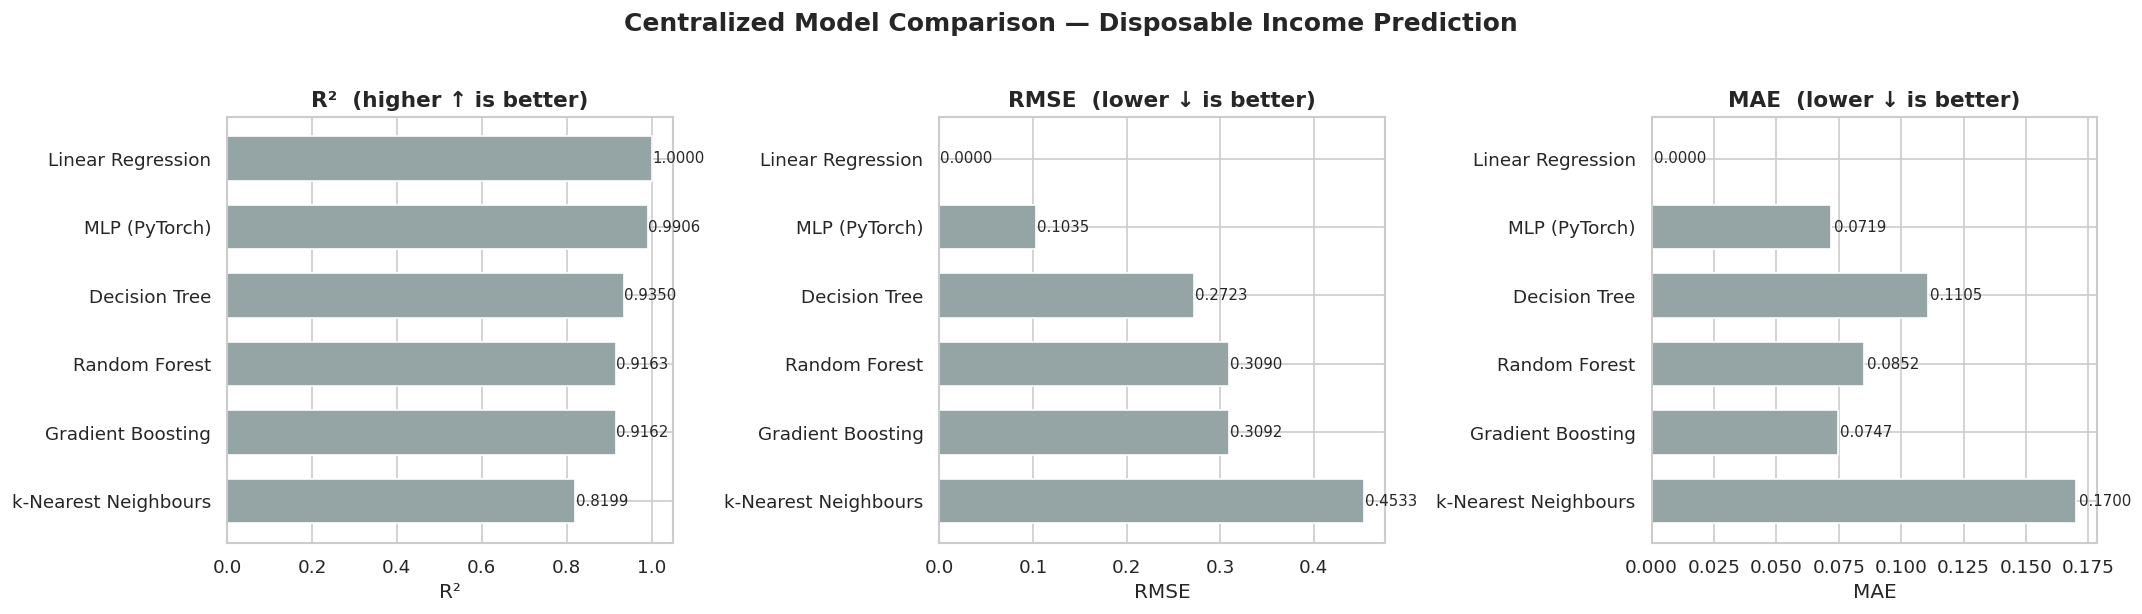

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names  = list(summary.index)
colors = ['#95a5a6' for n in names]

metrics = [
    ('R²',   True,  axes[0]),   # higher is better
    ('RMSE', False, axes[1]),   # lower is better
    ('MAE',  False, axes[2]),   # lower is better
]

for metric, higher_better, ax in metrics:
    vals = summary[metric].values
    bars = ax.barh(names, vals, color=colors, edgecolor='white', height=0.65)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric}  ({"higher ↑" if higher_better else "lower ↓"} is better)',
                 fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    # Annotate values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

fig.suptitle('Centralized Model Comparison — Disposable Income Prediction',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', bbox_inches='tight', dpi=150)
plt.show()